# AG-HYPOPT · Trial 11

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Ten trials. Leader: **trial_06** `cvm_fwhm` **0.0764** (sw 0.2074); same family sw 0.2345 -> 0.0777,
sw 0.1816 -> 0.0791; KDE control **0.080328**. The family-at-winning-sw checks are done for the
non-FWHM-only families: trial_09 `energy_2d` sw 0.2291 -> 0.1021 (no gain) and trial_10 `w1_2d` sw 0.2092
-> 0.0849 (small gain vs its 0.0895 at high sw, but still behind the control). So `cvm_fwhm` remains the
only family to beat the control, and it does so by a margin (~0.004) no other family approaches. Only
`w1_fwhm` has not been re-tested at the low sw. No divergences. Phase `trials` (10/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_11'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (10/5 trials)
ID |     ei | params
 1 | 1.9912 | {"loss_family": "w1_2d", "sigma_weight": 0.2240693847018223}
 2 | 1.8652 | {"loss_family": "kde", "sigma_weight": 0.9282110229603695}
 3 | 1.8659 | {"loss_family": "kde", "sigma_weight": 0.9483284532917751}
 4 | 2.3109 | {"loss_family": "w1_fwhm", "sigma_weight": 0.2061298429610274}
 5 | 0.6176 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.13796807286695534}
 6 | 3.2553 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.23177764875324394}
 7 | 2.9213 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19562117287981917}
 8 | 1.6467 | {"loss_family": "w1_2d", "sigma_weight": 0.19833385494108863}
 9 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.5915953039490435}
10 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.23530123166758055}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI again favours `cvm_fwhm` (candidates 6, 7 at sw 0.2318 / 0.1956). The winning sw trend is only
known at three points (0.1816, 0.2074, 0.2345), so the useful exploitation move is to **pin the minimum**:
candidate 7 at sw 0.1956 lands between the two best-valued points (0.1816 -> 0.0791 and 0.2074 -> 0.0764)
and will show whether the bottom sits below 0.2074 or the curve is flat there. Candidate 6 (sw 0.2318)
sits almost on trial_05's sw (0.2345) and is lower information. The other families are now mapped at low
sw (`w1_2d` 0.0849, `energy_2d` 0.1021) or clearly weak (`mmd_2d`); `w1_fwhm` at low sw (candidate 4)
is the one remaining coverage gap, but it is the FWHM-only twin of the already-tested `w1_2d` and is a
lower-value use of the trial than refining the leader.

I choose candidate 7.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19562117287981917}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.52 | γ 8.5 -> 5.92 | NLL 0.70


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 63.92 | γ 14.1 -> 13.92 | NLL 0.36


Running 3nW Trans100 ... 

μ 175.71 -> 96.86 | γ 14.1 -> 13.63 | NLL 0.21



Total: 7.8 min


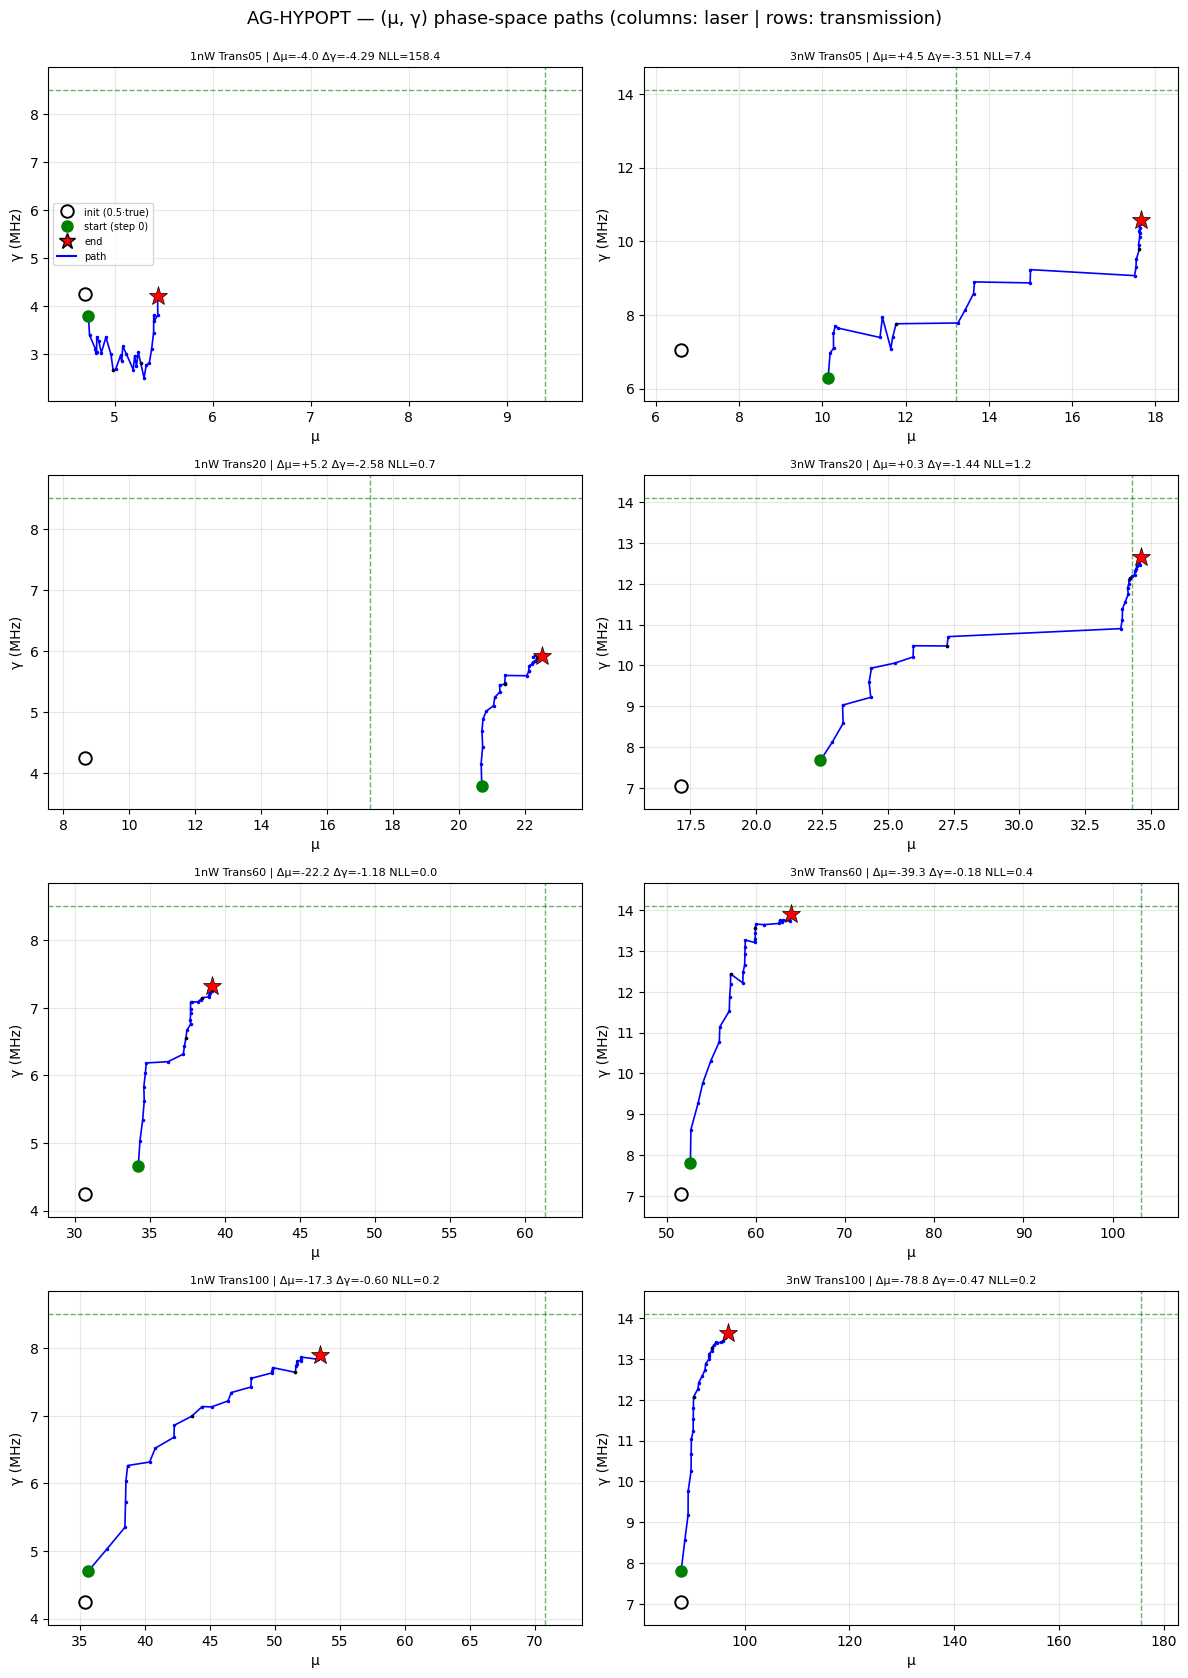

trial finished in 7.8 min
objective = 0.0760 ± 0.0200
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.52   +30.0 |     8.50    5.92   -30.4
1nW Trans60       61.37   39.16   -36.2 |     8.50    7.32   -13.9
1nW Trans100       70.82   53.47   -24.5 |     8.50    7.90    -7.0
3nW Trans05       13.20   17.67   +33.8 |    14.10   10.59   -24.9
3nW Trans20       34.28   34.63    +1.0 |    14.10   12.66   -10.2
3nW Trans60      103.20   63.92   -38.1 |    14.10   13.92    -1.3
3nW Trans100      175.71   96.86   -44.9 |    14.10   13.63    -3.3

weighted objective (T-graded, cap=1.0) = 0.0760 | diverged cells: 0
μ: RMSE 32.821 (rel 33.9%, bias -18.954) | γ: RMSE 2.276 (rel 23.6%, bias -1.780)


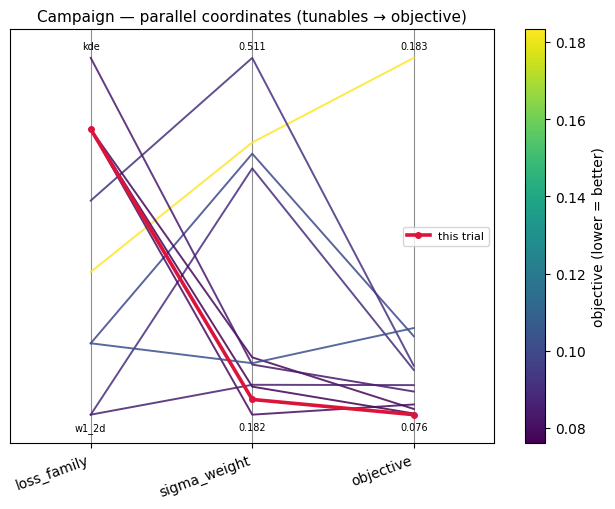

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1956}` (candidate 7). Trial
time 7.8 min, objective **0.0760 +/- 0.0200**, **0 diverged cells**. This is a **new campaign best**,
edging trial_06 (0.0764 at sw 0.2074) and comfortably under the KDE control (0.0803).

**The `cvm_fwhm` sw map now reads:** sw 0.1816 -> 0.0791, **sw 0.1956 -> 0.0760**, sw 0.2074 -> 0.0764,
sw 0.2345 -> 0.0777. The minimum is flat and sits around sw ~0.20 (0.1956-0.2074), with the curve rising
on both sides - so the optimum is now well bracketed.

**Per-cell behaviour.**

- 1nW Trans05: mu -42.1 %, gamma 8.5 -> 4.21 (-50.4 %) - identical to the other low-sw `cvm_fwhm` runs
  (this cell is sw-insensitive in the family).
- 1nW Trans20: mu +30.0 %, gamma -30.4 %.
- 1nW Trans60 / Trans100: mu -36.2 % / -24.5 %, gamma -13.9 % / -7.0 %.
- 3nW Trans05 / Trans20: mu +33.8 % / +1.0 %, gamma -24.9 % / -10.2 % (3nW Trans05 gamma the best
  low-count gamma of the campaign, -24.9 %).
- 3nW Trans60 / Trans100: mu -38.1 % / -44.9 %, gamma -1.3 % / -3.3 %.

**Aggregates.** mu: RMSE 32.82 (rel 33.9 %), bias -18.95; gamma: RMSE 2.28 (rel 23.6 %), bias -1.78 -
the **best gamma of the campaign** on every metric (previous best 2.40 / 24.2 %), and low-count gamma
improved again (1nW T05 -50.4 % vs -61 %/-67 % for the other families).

**Summary:** `cvm_fwhm` at sw 0.1956 sets a new campaign best of 0.0760, bracketing the family optimum
near sw ~0.20, with the campaign's best gamma recovery.
**Key insight:** The `cvm_fwhm` optimum is a flat basin around sw ~0.20 (0.0760-0.0764); its advantage over
the KDE control is driven by better gamma, especially in the low-count cells.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1956 sets a new campaign best of 0.0760, bracketing the family optimum near sw ~0.20, with the campaign best gamma recovery.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm optimum is a flat basin around sw ~0.20 (0.0760-0.0764); its advantage over the KDE control is driven by better gamma, especially in the low-count cells.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_11 | current best: trial_11


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_12.ipynb. Open it and follow its cells from the top.
